In [1]:
import pandas as pd
import numpy as np
import re

ucs_df = pd.read_csv("DATASETS_SATTELITES/ucs.csv")
spacetrack_df = pd.read_csv("DATASETS_SATTELITES/spacetrack_Full_Catalog.csv")
celestrack_df = pd.read_csv("DATASETS_SATTELITES/celestrack/celestrack_active.csv")

print(ucs_df.columns)
print(spacetrack_df.columns)
print(celestrack_df.columns)

Index(['Name of Satellite, Alternate Names',
       'Current Official Name of Satellite', 'Country/Org of UN Registry',
       'Country of Operator/Owner', 'Operator/Owner', 'Users', 'Purpose',
       'Detailed Purpose', 'Class of Orbit', 'Type of Orbit',
       'Longitude of GEO (degrees)', 'Perigee (km)', 'Apogee (km)',
       'Eccentricity', 'Inclination (degrees)', 'Period (minutes)',
       'Launch Mass (kg.)', ' Dry Mass (kg.) ', 'Power (watts)',
       'Date of Launch', 'Expected Lifetime (yrs.)', 'Contractor',
       'Country of Contractor', 'Launch Site', 'Launch Vehicle',
       'COSPAR Number', 'NORAD Number', 'Comments', 'Unnamed: 28',
       'Source Used for Orbital Data', 'Source', 'Source.1', 'Source.2',
       'Source.3', 'Source.4', 'Source.5', 'Source.6', 'Unnamed: 37',
       'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41',
       'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45',
       'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49',


In [11]:
import pandas as pd
import re

# Carregar os datasets
ucs_df = pd.read_csv("DATASETS_SATTELITES/ucs.csv", low_memory=False)
spacetrack_df = pd.read_csv("DATASETS_SATTELITES/spacetrack_Full_Catalog.csv")
celestrack_df = pd.read_csv("DATASETS_SATTELITES/celestrack_active.csv")

def ultra_clean(name):
    if pd.isna(name):
        return None
    # Remove aspas, limpa espaços e coloca em maiúsculas
    name = str(name).replace('"', '').strip().upper()
    # Remove múltiplos espaços internos
    name = " ".join(name.split())
    return name

# --- PROCESSAR UCS ---
# O título da coluna no seu CSV tem aspas e vírgula: "Name of Satellite, Alternate Names"
ucs_col = ucs_df.columns[0] # Pega a primeira coluna independente do nome exato
ucs_names = set()
for val in ucs_df[ucs_col].dropna():
    # Quebra nomes como "ABS-2 (Koreasat-8, ST-3)" em partes individuais
    parts = re.split(r'[/(,)]', str(val))
    for p in parts:
        cleaned = ultra_clean(p)
        if cleaned and len(cleaned) > 2:
            ucs_names.add(cleaned)

# --- PROCESSAR SPACE-TRACK ---
st_col = 'OBJECT_NAME'
spacetrack_names = set(spacetrack_df[st_col].apply(ultra_clean).dropna())

# --- PROCESSAR CELESTRAK ---
ct_col = 'OBJECT_NAME' if 'OBJECT_NAME' in celestrack_df.columns else 'object_name'
celestrack_names = set(celestrack_df[ct_col].apply(ultra_clean).dropna())

# --- COMPARAÇÕES ---
comuns_todos = ucs_names & spacetrack_names & celestrack_names
comuns_st_ct = spacetrack_names & celestrack_names # Devem ser quase iguais
comuns_ucs_st = ucs_names & spacetrack_names

print(f"Nomes únicos no UCS: {len(ucs_names)}")
print(f"Nomes únicos no Space-Track: {len(spacetrack_names)}")
print(f"Nomes únicos no Celestrak: {len(celestrack_names)}")
print("-" * 40)
print(f"1. Comuns aos TRÊS: {len(comuns_todos)}")
print(f"2. Comuns entre Space-Track e Celestrak: {len(comuns_st_ct)}")
print(f"3. Comuns entre UCS e Space-Track: {len(comuns_ucs_st)}")

# Exibir exemplos se houver
if comuns_todos:
    print("\nExemplos de nomes encontrados nos três datasets:")
    print(list(comuns_todos)[:10])

Nomes únicos no UCS: 9572
Nomes únicos no Space-Track: 18168
Nomes únicos no Celestrak: 14406
----------------------------------------
1. Comuns aos TRÊS: 4000
2. Comuns entre Space-Track e Celestrak: 11867
3. Comuns entre UCS e Space-Track: 4378

Exemplos de nomes encontrados nos três datasets:
['ONEWEB-0194', 'STARLINK-1269', 'STARLINK-1284', 'STARLINK-1876', 'IXPE', 'STARLINK-5464', 'STARLINK-4362', 'STARLINK-3647', 'O3B FM16', 'STARLINK-1209']


In [16]:
import pandas as pd

# 1. Carregar os datasets (ajuste os caminhos se necessário)
ucs_df = pd.read_csv("DATASETS_SATTELITES/ucs.csv", low_memory=False)
spacetrack_df = pd.read_csv("DATASETS_SATTELITES/spacetrack_Full_Catalog.csv", low_memory=False)
celestrack_df = pd.read_csv("DATASETS_SATTELITES/celestrack_active.csv", low_memory=False)

# 2. Identificar e Limpar as colunas de ID (NORAD Catalog Number)
# UCS: Coluna 'NORAD Number'
ucs_ids = set(pd.to_numeric(ucs_df['NORAD Number'], errors='coerce').dropna().astype(int))

# Space-Track: Normalmente 'NORAD_CAT_ID' ou 'norad_cat_id'
st_col = 'NORAD_CAT_ID' if 'NORAD_CAT_ID' in spacetrack_df.columns else 'norad_cat_id'
st_ids = set(pd.to_numeric(spacetrack_df[st_col], errors='coerce').dropna().astype(int))

# Celestrak: Normalmente 'NORAD_CAT_ID'
ct_col = 'NORAD_CAT_ID' if 'NORAD_CAT_ID' in celestrack_df.columns else 'norad_cat_id'
ct_ids = set(pd.to_numeric(celestrack_df[ct_col], errors='coerce').dropna().astype(int))

# 3. Calcular as Interseções (Onde os IDs são iguais)
comum_todos = ucs_ids.intersection(st_ids).intersection(ct_ids)
comum_ucs_st = ucs_ids.intersection(st_ids)
comum_st_ct = st_ids.intersection(ct_ids)

# 4. Exibir os resultados finais
print(f"{'DATASET':<15} | {'IDS ÚNICOS':<10}")
print("-" * 30)
print(f"{'UCS':<15} | {len(ucs_ids)}")
print(f"{'Space-Track':<15} | {len(st_ids)}")
print(f"{'Celestrak':<15} | {len(ct_ids)}")
print("\n" + "="*40)
print(f"Satelites em comum nos TRÊS: {len(comum_todos)}")
print(f"Satelites em comum UCS & Space-Track: {len(comum_ucs_st)}")
print(f"Satelites em comum Space-Track & Celestrak: {len(comum_st_ct)}")
print("="*40)

# Exemplo dos primeiros 5 IDs que batem em todos
if comum_todos:
    print(f"\nExemplo de IDs comuns: {sorted(list(comum_todos))[:5]}")

DATASET         | IDS ÚNICOS
------------------------------
UCS             | 7551
Space-Track     | 32983
Celestrak       | 14408

Satelites em comum nos TRÊS: 5237
Satelites em comum UCS & Space-Track: 5552
Satelites em comum Space-Track & Celestrak: 14407

Exemplo de IDs comuns: [7530, 19548, 20253, 20580, 20776]


In [17]:
print(ucs_df["Purpose"].unique())

<StringArray>
[                             'Earth Observation',
                         'Technology Development',
                                 'Communications',
                                  'Earth Science',
                                  'Space Science',
         'Space Science/Technology Demonstration',
          'Communications/Technology Development',
               'Communications/Maritime Tracking',
                       'Technology Demonstration',
                                        'Unknown',
                  'Navigation/Global Positioning',
       'Earth Observation/Technology Development',
                             'Earth Observation ',
               'Earth Observation/Communications',
                        'Earth/Space Observation',
                                    'Educational',
                'Earth Observation/Earth Science',
                                       'Platform',
                'Earth Observation/Space Science',
                 

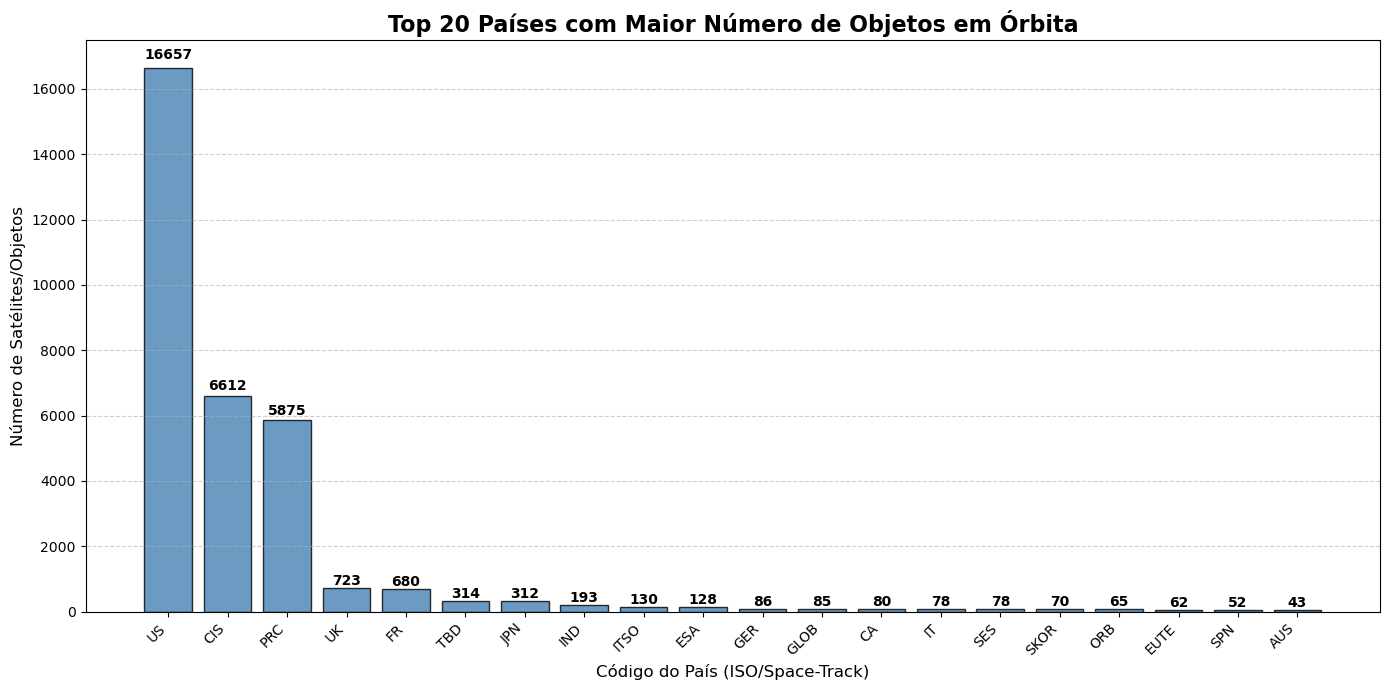

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Contar as ocorrências de cada país e ordenar
country_counts = spacetrack_df['COUNTRY'].value_counts().sort_values(ascending=False)

# 2. Selecionar apenas os Top 20 para garantir legibilidade
top_20_countries = country_counts.head(20)

# 3. Criar o gráfico
plt.figure(figsize=(14, 7))
bars = plt.bar(top_20_countries.index, top_20_countries.values, color='steelblue', edgecolor='black', alpha=0.8)

# 4. Configurar Títulos e Legendas
plt.title('Top 20 Países com Maior Número de Objetos em Órbita', fontsize=16, fontweight='bold')
plt.xlabel('Código do País (ISO/Space-Track)', fontsize=12)
plt.ylabel('Número de Satélites/Objetos', fontsize=12)

# 5. Adicionar os valores exatos por cima de cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.01), int(yval), 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# 6. Melhorar a estética (remover bordas desnecessárias e adicionar grelha)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=45, ha='right') # Rodar 45 graus para não sobrepor
plt.tight_layout()

# 7. Guardar o gráfico
plt.savefig('bar_plot_countries.png', dpi=300)
plt.show()
